<a href="https://colab.research.google.com/github/TyraNyamburaa/personal-projects/blob/main/TerraWatch_datasets_from_google_earth.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Authenticate and initialize code

In [1]:
import ee

# Trigger the Earth Engine authentication flow
ee.Authenticate()

# Initialize the Earth Engine library
ee.Initialize(project='terrawatch-510217')

*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


## Define Rwanda's Boundary
Before pulling the global rainfall data, we need a spatial boundary to isolate just Rwanda.

In [2]:
# Load the official global administrative boundary and filter for Rwanda
rwanda_boundary = ee.FeatureCollection('FAO/GAUL/2015/level0').filter(
    ee.Filter.eq('ADM0_NAME', 'Rwanda')
)

## Load and filter the historical rainfall collection
Now, we call the exact collection from the table (UCSB-CHC/CHIRPS/V3/DAILY_RNL). We will filter it spatially to Rwanda and set a date range 2006 - 2021.

In [3]:
# Load the CHIRPS Historical Daily Rainfall collection
historical_rainfall = (
    ee.ImageCollection('UCSB-CHC/CHIRPS/V3/DAILY_RNL')
    .filterBounds(rwanda_boundary)  # Limit data geographically to Rwanda
    .filterDate(
        '2006-01-01', '2021-01-01'
    )
)

# Check how many daily rainfall images are in your filtered collection
count = historical_rainfall.size().getInfo()
print(f'Total daily rainfall images loaded: {count}')

Total daily rainfall images loaded: 5479


## Validation script
This script loops through each year from 2006 to 2021, counts the images, and verifies if they perfectly match 365 days (or 366 for leap years) with no duplicates or missing dates.

In [4]:
import pandas as pd

# 1. Load the official Rwanda National Boundary (Level 0)
rwanda_country = ee.FeatureCollection('FAO/GAUL/2015/level0').filter(
    ee.Filter.eq('ADM0_NAME', 'Rwanda')
)

# 2. Define our target year range for the landslide inventory
start_year = 2006
end_year = 2021

print('Validating CHIRPS V3 Daily Reanalysis for Rwanda')

# Loop through each year to verify data completeness before export
for year in range(start_year, end_year + 1):
    start_date = f'{year}-01-01'
    end_date = f'{year+1}-01-01'

    # Filter collection for the current year over Rwanda
    yearly_collection = (
        ee.ImageCollection('UCSB-CHC/CHIRPS/V3/DAILY_RNL')
        .filterBounds(rwanda_country)
        .filterDate(start_date, end_date)
    )

    # Get the total count of images
    img_count = yearly_collection.size().getInfo()

    # Extract all system:time_start properties to check for unique dates
    date_list = (
        yearly_collection.aggregate_array('system:time_start').getInfo()
    )
    unique_dates = len(set(date_list))

    # Determine expected days (handling leap years)
    is_leap = (
        (year % 4 == 0 and year % 100 != 0) or (year % 400 == 0)
    )
    expected_days = 366 if is_leap else 365

    # Check for anomalies
    status = 'PERFECT'
    if img_count != expected_days:
        status = f'MISMATCH (Got {img_count}, Expected {expected_days})'
    elif unique_dates != img_count:
        status = 'DUPLICATE DATES FOUND'

    print(f'Year {year}: {img_count} images | Unique dates: {unique_dates} | Status: {status}')


Validating CHIRPS V3 Daily Reanalysis for Rwanda
Year 2006: 365 images | Unique dates: 365 | Status: PERFECT
Year 2007: 365 images | Unique dates: 365 | Status: PERFECT
Year 2008: 366 images | Unique dates: 366 | Status: PERFECT
Year 2009: 365 images | Unique dates: 365 | Status: PERFECT
Year 2010: 365 images | Unique dates: 365 | Status: PERFECT
Year 2011: 365 images | Unique dates: 365 | Status: PERFECT
Year 2012: 366 images | Unique dates: 366 | Status: PERFECT
Year 2013: 365 images | Unique dates: 365 | Status: PERFECT
Year 2014: 365 images | Unique dates: 365 | Status: PERFECT
Year 2015: 365 images | Unique dates: 365 | Status: PERFECT
Year 2016: 366 images | Unique dates: 366 | Status: PERFECT
Year 2017: 365 images | Unique dates: 365 | Status: PERFECT
Year 2018: 365 images | Unique dates: 365 | Status: PERFECT
Year 2019: 365 images | Unique dates: 365 | Status: PERFECT
Year 2020: 366 images | Unique dates: 366 | Status: PERFECT
Year 2021: 365 images | Unique dates: 365 | Status:

## Run the export script

In [5]:
# Loop through each verified year and trigger a multi-band export task
for year in range(2006, 2022):
    start_date = f'{year}-01-01'
    end_date = f'{year+1}-01-01'

    # 1. Filter the daily rainfall collection for the specific year
    yearly_coll = (
        ee.ImageCollection('UCSB-CHC/CHIRPS/V3/DAILY_RNL')
        .filterBounds(rwanda_country)
        .filterDate(start_date, end_date)
        .select('precipitation')
    )

    # 2. Convert the collection of individual daily images into a single multi-band image
    # Each daily image becomes a numbered band (e.g., band 0 is Jan 1st)
    yearly_multiband = yearly_coll.toBands().clip(rwanda_country)

    # 3. Export task to Google Drive
    task = ee.batch.Export.image.toDrive(
        image=yearly_multiband,
        description=f'Rwanda_CHIRPS_DAILY_RNL_{year}',
        folder='TerraWatch_Rainfall_Data',  # Creates a folder with this name in the Drive
        scale=5600,  # CHIRPS native spatial resolution (~5.6 km)
        region=rwanda_country.geometry(),
        fileFormat='GeoTIFF',
    )

    # 4. Start the cloud processing task
    task.start()
    print(f'Started Google Drive export task for year: {year}')

print(
    '\nAll tasks successfully submitted! Processing is handling on Google Cloud servers.'
)


Started Google Drive export task for year: 2006
Started Google Drive export task for year: 2007
Started Google Drive export task for year: 2008
Started Google Drive export task for year: 2009
Started Google Drive export task for year: 2010
Started Google Drive export task for year: 2011
Started Google Drive export task for year: 2012
Started Google Drive export task for year: 2013
Started Google Drive export task for year: 2014
Started Google Drive export task for year: 2015
Started Google Drive export task for year: 2016
Started Google Drive export task for year: 2017
Started Google Drive export task for year: 2018
Started Google Drive export task for year: 2019
Started Google Drive export task for year: 2020
Started Google Drive export task for year: 2021

All tasks successfully submitted! Processing is handling on Google Cloud servers.


## Mount the Google Drive in Colab

In [6]:
from google.colab import drive

# Force an explicit session verification
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


## Inspection script
This will install rasterio (a geospatial data tool), open your downloaded .tif file from the local Colab path or Drive, and print out its inner array dimensions and metadata to confirm the data exists:

GeoTIFF integrity check
Metadata Profile: {'driver': 'GTiff', 'dtype': 'float32', 'nodata': None, 'width': 42, 'height': 37, 'count': 365, 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'), 'transform': Affine(0.050305655910693206, 0.0, 28.8187776852875,
       0.0, -0.050305655910693206, -1.0207606196708596), 'blockxsize': 256, 'blockysize': 256, 'tiled': True, 'compress': 'lzw', 'interleave': 'pixel'}

Image Width: 42 pixels
Image Height: 37 pixels
Total Daily Bands Loaded: 365 layers
Maximum rainfall recorded on Day 1: nan mm


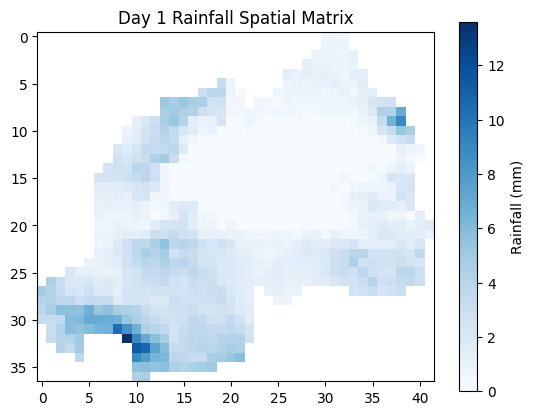

In [7]:
import rasterio
import matplotlib.pyplot as plt

# Updated path to look inside your mounted Google Drive folder
tiff_path = '/content/drive/MyDrive/TerraWatch_Rainfall_Data/Rwanda_CHIRPS_DAILY_RNL_2006.tif'

with rasterio.open(tiff_path) as src:
    print('GeoTIFF integrity check')
    print(f'Metadata Profile: {src.profile}\n')
    print(f'Image Width: {src.width} pixels')
    print(f'Image Height: {src.height} pixels')
    print(f'Total Daily Bands Loaded: {src.count} layers')

    # Read the first band (Day 1) to verify data exists
    first_day_data = src.read(1)
    max_rainfall = first_day_data.max()
    print(f'Maximum rainfall recorded on Day 1: {max_rainfall:.2f} mm')

    # Quick plot to visualize the geospatial matrix
    plt.imshow(first_day_data, cmap='Blues')
    plt.colorbar(label='Rainfall (mm)')
    plt.title('Day 1 Rainfall Spatial Matrix')
    plt.show()

In [8]:
import datetime

# 1. Load the Recent Satellite Daily Rainfall collection
recent_satellite_collection = ee.ImageCollection(
    'UCSB-CHC/CHIRPS/V3/DAILY_SAT'
)

# 2. Get the date of the very last image uploaded to this collection
latest_meta = recent_satellite_collection.sort('system:time_start', False).first()
latest_timestamp = latest_meta.get('system:time_start').getInfo()

# 3. Convert the timestamp into a human-readable date
latest_date = datetime.datetime.fromtimestamp(
    latest_timestamp / 1000, tz=datetime.timezone.utc
).strftime('%Y-%m-%d')

print(f'The latest available date for DAILY_SAT is: {latest_date}')

The latest available date for DAILY_SAT is: 2026-08-31


## Run the district export script

In [9]:
# 1. Load the official Level 1 administrative boundaries for Rwanda (Districts)
rwanda_districts = ee.FeatureCollection('FAO/GAUL/2015/level1').filter(
    ee.Filter.eq('ADM0_NAME', 'Rwanda')
)

# 2. Set up the vector export task to your Google Drive folder
vector_task = ee.batch.Export.table.toDrive(
    collection=rwanda_districts,
    description='Rwanda_District_Boundaries_2015',
    folder='TerraWatch_Boundaries',  # Creates a specific folder for boundaries
    fileFormat='GeoJSON',  # Ideal format for your dashboard map views
    selectors=['ADM1_NAME', 'ADM1_CODE'],  # Keeps the district name and unique ID metadata
)

# 3. Start the export task on the cloud
vector_task.start()

print(
    'Export task started! Google Cloud is generating your Rwanda District GeoJSON.'
)
print('You can monitor it under the "Tasks" tab in your GEE Code Editor.')

/usr/local/lib/python3.13/dist-packages/ee/deprecation.py:215: DeprecationWarning: 

Attention required for FAO/GAUL/2015/level1! You are using a deprecated asset.
To make sure your code keeps working, please update it.
This dataset has been superseded by FAO/GAUL/2025/level1

Learn more: https://developers.google.com/earth-engine/datasets/catalog/FAO_GAUL_2015_level1

  warnings.warn(warning, category=DeprecationWarning)


Export task started! Google Cloud is generating your Rwanda District GeoJSON.
You can monitor it under the "Tasks" tab in your GEE Code Editor.


## Run the rolling totals calculator
Script that automates the generation of the 1, 3, 7, 10, and 30-day rolling accumulation totals across all years from 2006 to 2021 [1, 3, 7, 10, and 30-day rainfall totals].

In [10]:
import os
import numpy as np
import rasterio

# Define base folder configurations
base_dir = '/content/drive/MyDrive/TerraWatch-datasets/chirps-historical-rainfall-datasets'
years = range(2006, 2022)
windows = [1, 3, 7, 10, 30]

print('Launching TerraWatch multi-day antecedent rainfall batch pipeline...\n')

for year in years:
    input_file = os.path.join(base_dir, f'Rwanda_CHIRPS_DAILY_RNL_{year}.tif')

    # Quick safety check to verify if the raw annual dataset is present
    if not os.path.exists(input_file):
        print(f'Skipping {year}: Input file not found at {input_file}')
        continue

    print(f'Processing Year: {year}')

    with rasterio.open(input_file) as src:
        # Read the raw daily rainfall layers (Bands, Height, Width)
        # band index 0 maps to January 1st
        raw_rainfall = src.read()
        meta = src.profile.copy()

        num_bands, height, width = raw_rainfall.shape

        # Calculate each requested window index sequence
        for w in windows:
            # For a 1-day total, it is simply the exact raw value array
            if w == 1:
                rolling_totals = raw_rainfall.copy()
            else:
                # Initialize an empty array matching the dimension schema
                rolling_totals = np.zeros_like(raw_rainfall)

                # Accumulate backwards matching the temporal window frame length
                for t in range(w - 1, num_bands):
                    # Sum up slice values from (t - w + 1) up to t inclusive
                    rolling_totals[t] = np.sum(raw_rainfall[t - w + 1 : t + 1], axis=0)

            # Formulate clear tracking name strings
            output_filename = f'Rwanda_{w}Day_Rolling_Totals_{year}.tif'
            output_filepath = os.path.join(base_dir, output_filename)

            # Verify profile metadata explicitly matches output requirements
            meta.update(dtype=rasterio.float32, count=num_bands)

            # Commit the computed multidimensional array block directly back to Drive
            with rasterio.open(output_filepath, 'w', **meta) as dst:
                dst.write(rolling_totals.astype(rasterio.float32))

            print(f'Generated {w}-day profile: {output_filename}')

print('\nAll multi-day historical antecedent intervals completed successfully!')


Launching TerraWatch multi-day antecedent rainfall batch pipeline...

Processing Year: 2006
Generated 1-day profile: Rwanda_1Day_Rolling_Totals_2006.tif
Generated 3-day profile: Rwanda_3Day_Rolling_Totals_2006.tif
Generated 7-day profile: Rwanda_7Day_Rolling_Totals_2006.tif
Generated 10-day profile: Rwanda_10Day_Rolling_Totals_2006.tif
Generated 30-day profile: Rwanda_30Day_Rolling_Totals_2006.tif
Processing Year: 2007
Generated 1-day profile: Rwanda_1Day_Rolling_Totals_2007.tif
Generated 3-day profile: Rwanda_3Day_Rolling_Totals_2007.tif
Generated 7-day profile: Rwanda_7Day_Rolling_Totals_2007.tif
Generated 10-day profile: Rwanda_10Day_Rolling_Totals_2007.tif
Generated 30-day profile: Rwanda_30Day_Rolling_Totals_2007.tif
Processing Year: 2008
Generated 1-day profile: Rwanda_1Day_Rolling_Totals_2008.tif
Generated 3-day profile: Rwanda_3Day_Rolling_Totals_2008.tif
Generated 7-day profile: Rwanda_7Day_Rolling_Totals_2008.tif
Generated 10-day profile: Rwanda_10Day_Rolling_Totals_2008.tif


## Verify Recent Daily Rainfall Data `(UCSB-CHC/CHIRPS/V3/DAILY_SAT)`
Since the clean MINEMA inventory runs through the end of 2025, the training window must capture recent landslide dates. We already confirmed that the platform's near-real-time satellite stream goes up to August 31, 2026.
Let’s add a code cell to download the multi-band recent rainfall blocks specifically covering 2022 to 2025 to completely bridge the time gap.

In [11]:
# Loop through the remaining recent baseline years
for year in range(2022, 2026):
    start_date = f'{year}-01-01'
    end_date = f'{year+1}-01-01'

    # Pull the satellite-derived DAILY_SAT collection instead of reanalysis
    recent_coll = (
        ee.ImageCollection('UCSB-CHC/CHIRPS/V3/DAILY_SAT')
        .filterBounds(rwanda_country)
        .filterDate(start_date, end_date)
        .select('precipitation')
    )

    recent_multiband = recent_coll.toBands().clip(rwanda_country)

    task = ee.batch.Export.image.toDrive(
        image=recent_multiband,
        description=f'Rwanda_CHIRPS_DAILY_SAT_{year}',
        folder='chirps-historical-rainfall-datasets',  # Pushes directly into the active folder
        scale=5600,
        region=rwanda_country.geometry(),
        fileFormat='GeoTIFF',
    )
    task.start()
    print(f'Started Drive export task for recent year: {year}')


Started Drive export task for recent year: 2022
Started Drive export task for recent year: 2023
Started Drive export task for recent year: 2024
Started Drive export task for recent year: 2025


## Extract static land cover layer (ESA/WorldCover/v100)
To capture static landslide-susceptibility factors (such as bare ground vs. cropland or forest canopy), we need a land-cover baseline.
The ESA WorldCover dataset provides high-accuracy 10-meter global classification maps.
We will fetch the data, match its dimensions, and drop it straight into the datasets folder.

In [12]:
# 1. Grab the global 10m ESA WorldCover image mosaic
esa_worldcover = (
    ee.ImageCollection('ESA/WorldCover/v100').first().clip(rwanda_country)
)

# 2. Export the land cover classification map to the Drive
lc_task = ee.batch.Export.image.toDrive(
    image=esa_worldcover.select('Map'),
    description='Rwanda_ESA_WorldCover_10m',
    folder='TerraWatch_Boundaries',  # Groups it alongside the static vector assets
    scale=10,  # Full native 10-meter spatial fidelity
    region=rwanda_country.geometry(),
    fileFormat='GeoTIFF',
)
lc_task.start()
print('Started ESA WorldCover export task!')


Started ESA WorldCover export task!


## Extract pixel-level rainfall for landslide labels
Since some records in the clean MINEMA inventory contain precise coordinates, we can match those exact latitude and longitude points against the multi-band CHIRPS .tif layers.

This script loops through each valid row, reads the corresponding year's file directly from the Google Drive, and pulls the antecedent rainfall trace leading up to the landslide date.

In [13]:
import pandas as pd
import numpy as np
import rasterio
from datetime import datetime

# 1. Load your clean MINEMA CSV file
csv_path = '/content/drive/MyDrive/TerraWatch-datasets/MINEMA-Clean-datasets/rwanda_minema_landslide_inventory_clean.csv'
df = pd.read_csv(csv_path)

# Filter for rows that actually have valid, precise geocoded coordinates
df_valid = df.dropna(subset=['latitude', 'longitude']).copy()
df_valid['event_date'] = pd.to_datetime(df_valid['event_date'])

print(f"Found {len(df_valid)} precisely geocoded landslide points for value extraction.")

# Dictionary to hold our matched features
extracted_records = []

# base folder configuration for rainfall
rainfall_dir = '/content/drive/MyDrive/TerraWatch-datasets/chirps-historical-rainfall-datasets'

# 2. Iterate through rows and extract cell values
for idx, row in df_valid.iterrows():
    evt_id = row['event_id']
    lon, lat = row['longitude'], row['latitude']
    date = row['event_date']
    year = date.year

    # Target the correct annual reanalysis file matching the event year
    tif_name = f'Rwanda_CHIRPS_DAILY_RNL_{year}.tif' if year <= 2021 else f'Rwanda_CHIRPS_DAILY_SAT_{year}.tif'
    tif_path = f"{rainfall_dir}/{tif_name}"

    try:
        with rasterio.open(tif_path) as src:
            # Sample the pixel value at the exact Lat/Lon coordinate location
            row_idx, col_idx = src.index(lon, lat)

            # Read all daily bands for this specific pixel coordinate point
            pixel_time_series = src.read(window=((row_idx, row_idx+1), (col_idx, col_idx+1))).flatten()

            # Calculate the day of the year (1-index based index array tracking)
            day_of_year = date.timetuple().tm_yday

            # Pull matching multi-day windows leading up to the landslide index point
            # Note: Python index steps backward from current day array marker
            rain_1d = pixel_time_series[day_of_year - 1] if day_of_year >= 1 else 0
            rain_3d = np.sum(pixel_time_series[max(0, day_of_year-3):day_of_year])
            rain_7d = np.sum(pixel_time_series[max(0, day_of_year-7):day_of_year])
            rain_10d = np.sum(pixel_time_series[max(0, day_of_year-10):day_of_year])
            rain_30d = np.sum(pixel_time_series[max(0, day_of_year-30):day_of_year])

            extracted_records.append({
                'event_id': evt_id,
                'event_date': date.strftime('%Y-%m-%d'),
                'latitude': lat,
                'longitude': lon,
                'rain_1day': rain_1d,
                'rain_3day': rain_3d,
                'rain_7day': rain_7d,
                'rain_10day': rain_10d,
                'rain_30day': rain_30d
            })
    except Exception as e:
        # Skips cleanly if a recent year file is still rendering on the drive cloud server
        continue

# 3. Create a model-ready dataframe matrix
model_ready_df = pd.DataFrame(extracted_records)
output_matrix_path = '/content/drive/MyDrive/TerraWatch-datasets/MINEMA-Clean-datasets/TerraWatch_Model_Training_Matrix.csv'
model_ready_df.to_csv(output_matrix_path, index=False)

print(f"\nExtraction matrix compiled successfully! Saved to: {output_matrix_path}")
print(model_ready_df.head())


Found 0 precisely geocoded landslide points for value extraction.

Extraction matrix compiled successfully! Saved to: /content/drive/MyDrive/TerraWatch-datasets/MINEMA-Clean-datasets/TerraWatch_Model_Training_Matrix.csv
Empty DataFrame
Columns: []
Index: []


## Pull the Digital Elevation Model (DEM) & Slope Layers
Landslides don't occur on completely flat terrain. To append static topographic attributes (elevation and slope angles) to the training data matrix, we will extract the NASA `NASADEM` Global 30m dataset directly from Google Earth Engine.

In [14]:
# 1. Load the official National Boundary baseline to clip the topographic data
rwanda_country = ee.FeatureCollection('FAO/GAUL/2015/level0').filter(
    ee.Filter.eq('ADM0_NAME', 'Rwanda')
)

# 2. Call the NASA NASADEM image asset collection layer
nasadem = ee.Image('NASA/NASADEM_HGT/001').clip(rwanda_country)

# 3. Extract elevation values and float type alignment conversion
elevation = nasadem.select('elevation').toFloat()
slope = ee.Terrain.slope(elevation).toFloat()

# Combine both float topographical variables into a single uniform multiband raster layer
terrain_stack = ee.Image.cat([elevation, slope])

# 4. Trigger an export task with explicitly higher pixel thresholds
dem_task = ee.batch.Export.image.toDrive(
    image=terrain_stack,
    description='Rwanda_NASADEM_Topography_30m_Fixed',
    folder='TerraWatch_Boundaries',
    scale=30,  # Native 30-meter high resolution grid mapping
    region=rwanda_country.geometry(),
    fileFormat='GeoTIFF',
    maxPixels=1e9  # Expanded pixel capacity cap to clear the area limit error code
)

dem_task.start()
print("Patched export task started for 30m Topography DEM & Slope Layers!")
print("The data type alignment and pixel capacity limits have been successfully expanded.")


Patched export task started for 30m Topography DEM & Slope Layers!
The data type alignment and pixel capacity limits have been successfully expanded.


## Land cover exporter script

In [15]:
# 1. Grab the global 10m ESA WorldCover image mosaic layer bounded to Rwanda
esa_worldcover = (
    ee.ImageCollection('ESA/WorldCover/v100').first().clip(rwanda_country)
)

# 2. Trigger the export task with explicitly higher pixel thresholds to prevent crashes
lc_task_fixed = ee.batch.Export.image.toDrive(
    image=esa_worldcover.select('Map'),
    description='Rwanda_ESA_WorldCover_10m_Fixed',
    folder='TerraWatch_Boundaries',  # Groups it alongside the static vector assets
    scale=10,  # Full native 10-meter spatial high-fidelity resolution grid mapping
    region=rwanda_country.geometry(),
    fileFormat='GeoTIFF',
    maxPixels=1e9,  # Expanded pixel capacity threshold parameter to bypass the size error limits
)

# Start the cloud operation task
lc_task_fixed.start()
print('Patched export task submitted for 10m ESA Land Cover classification layer!')


Patched export task submitted for 10m ESA Land Cover classification layer!
